In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
data = pd.read_csv(r"C:\Users\Chandan\OneDrive\Documents\EMAIL PHSHING CSV\phishing_email.csv")

In [3]:
data.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82486 entries, 0 to 82485
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text_combined  82486 non-null  object
 1   label          82486 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [5]:
data.shape

(82486, 2)

In [6]:
data.isnull().sum()

text_combined    0
label            0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(408)

In [8]:
data.drop_duplicates(inplace=True)

In [ ]:
Class Distribution

In [9]:
data["label"].value_counts()

label
1    42845
0    39233
Name: count, dtype: int64

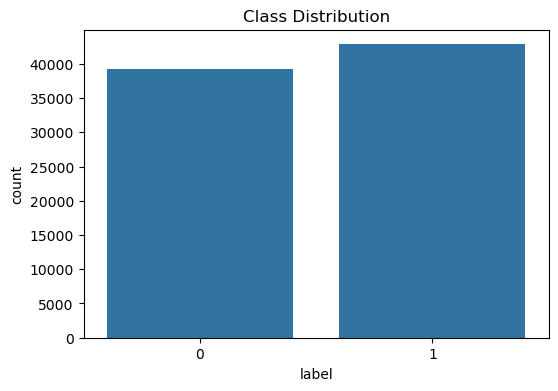

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x="label",data=data)

plt.title("Class Distribution")

plt.show()

In [11]:
data["text_combined"] = data["text_combined"].str.lower()

In [12]:
data.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [13]:
data.dropna(inplace=True)

In [14]:
import re
import string

import nltk

from nltk.corpus import stopwords

from nltk.stem import WordNetLemmatizer

In [15]:
nltk.download("stopwords")

nltk.download("wordnet")

nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Chandan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Chandan\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Chandan\AppData\Roaming\nltk_data...


True

In [16]:
stop_words = set(stopwords.words("english"))

In [17]:
lemmatizer = WordNetLemmatizer()

In [ ]:
Create Text Cleaning Function

In [18]:
def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove Numbers
    text = re.sub(r"\d+", "", text)

    # Remove Punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove Extra Spaces
    text = text.strip()

    # Tokenization
    words = text.split()

    # Remove Stopwords
    words = [word for word in words if word not in stop_words]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [11]:
data["clean_text"] = data["text_combined"].apply(clean_text)

In [20]:
data[["text_combined","clean_text"]].head()

,text_combined,clean_text
0,hpl nom may 25 2001 see attached file hplno 52...,hpl nom may see attached file hplno xl hplno xl
1,nom actual vols 24 th forwarded sabrae zajac h...,nom actual vols th forwarded sabrae zajac hou ...
2,enron actuals march 30 april 1 201 estimated a...,enron actuals march april estimated actuals ma...
3,hpl nom may 30 2001 see attached file hplno 53...,hpl nom may see attached file hplno xl hplno xl
4,hpl nom june 1 2001 see attached file hplno 60...,hpl nom june see attached file hplno xl hplno xl


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(data["clean_text"])

y = data["label"]

In [22]:
print(X.shape)

print(y.shape)

(82078, 5000)
(82078,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

print("Train Shape :", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape : (65988, 5000)
Test Shape : (16498, 5000)


In [24]:
print(X_train.shape)

print(X_test.shape)

(65662, 5000)
(16416, 5000)


In [ ]:
MODEL TRAINING

In [ ]:
MODEL 1 : Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [28]:
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [29]:
y_pred_lr = lr_model.predict(X_test)

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
ACCURACY

In [31]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy :", lr_accuracy)

Accuracy : 0.9798976608187134


In [ ]:
PRECISION

In [32]:
lr_precision = precision_score(y_test, y_pred_lr)

print("Precision :", lr_precision)

Precision : 0.9786220518182874


In [ ]:
RECALL

In [33]:
lr_recall = recall_score(y_test, y_pred_lr)

print("Recall :", lr_recall)

Recall : 0.9829618391877699


In [ ]:
F1 SCORE

In [34]:
lr_f1 = f1_score(y_test, y_pred_lr)

print("F1 Score :", lr_f1)

F1 Score : 0.9807871448532837


In [ ]:
CLASSIFICATION REPORT

In [35]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7847
           1       0.98      0.98      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416



In [36]:
cm = confusion_matrix(y_test, y_pred_lr)

cm

array([[7663,  184],
       [ 146, 8423]])

In [ ]:
CONFUSION MATRIX

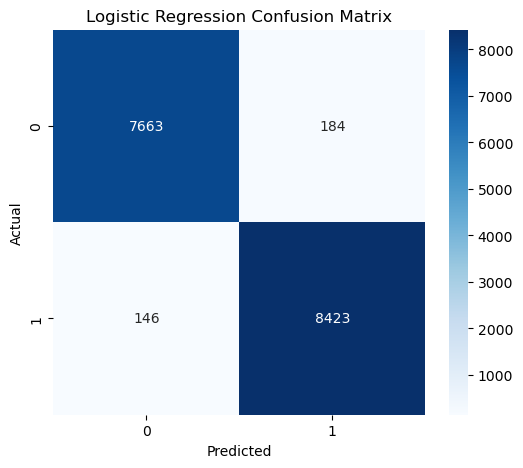

In [40]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [38]:
logistic_results = {

    "Accuracy": lr_accuracy,

    "Precision": lr_precision,

    "Recall": lr_recall,

    "F1 Score": lr_f1

}

logistic_results

{'Accuracy': 0.9798976608187134,
 'Precision': 0.9786220518182874,
 'Recall': 0.9829618391877699,
 'F1 Score': 0.9807871448532837}

In [ ]:
MODEL 2 : Naive Bayes

In [41]:
from sklearn.naive_bayes import MultinomialNB

In [42]:
nb_model = MultinomialNB()

In [43]:
nb_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [44]:
y_pred_nb = nb_model.predict(X_test)

In [ ]:
Accuracy

In [45]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Accuracy :", nb_accuracy)

Accuracy : 0.9604044834307992


In [ ]:
Precision

In [46]:
nb_precision = precision_score(y_test, y_pred_nb)

print("Precision :", nb_precision)

Precision : 0.9744757339724386


In [ ]:
Recall

In [47]:
nb_recall = recall_score(y_test, y_pred_nb)

print("Recall :", nb_recall)

Recall : 0.9490022172949002


In [ ]:
F1 Score

In [49]:
nb_f1 = f1_score(y_test, y_pred_nb)

print("F1 Score :", nb_f1)

F1 Score : 0.961570296795554


In [ ]:
Classfication Report

In [50]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      7847
           1       0.97      0.95      0.96      8569

    accuracy                           0.96     16416
   macro avg       0.96      0.96      0.96     16416
weighted avg       0.96      0.96      0.96     16416



In [ ]:
Confusion Matrix

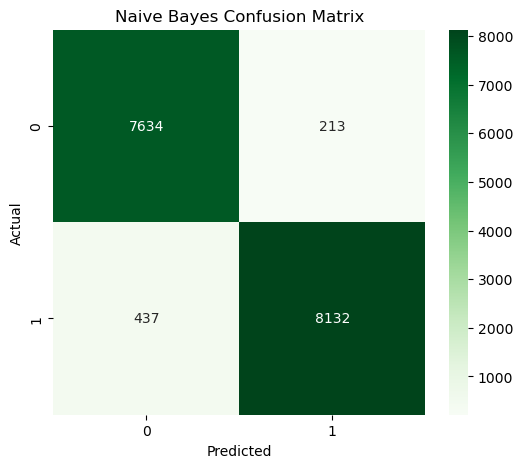

In [51]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Naive Bayes Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [52]:
naive_results = {

    "Accuracy": nb_accuracy,

    "Precision": nb_precision,

    "Recall": nb_recall,

    "F1 Score": nb_f1

}

naive_results

{'Accuracy': 0.9604044834307992,
 'Precision': 0.9744757339724386,
 'Recall': 0.9490022172949002,
 'F1 Score': 0.961570296795554}

In [ ]:
MODEL 3 : Random Forest

In [53]:
from sklearn.ensemble import RandomForestClassifier

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("✅ Random Forest Model Trained Successfully!")

✅ Random Forest Model Trained Successfully!


In [55]:
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
y_pred_rf = rf_model.predict(X_test)

In [57]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(y_test, y_pred_rf)

rf_recall = recall_score(y_test, y_pred_rf)

rf_f1 = f1_score(y_test, y_pred_rf)

In [58]:
print("Accuracy :", rf_accuracy)

print("Precision :", rf_precision)

print("Recall :", rf_recall)

print("F1 :", rf_f1)

Accuracy : 0.9842836257309941
Precision : 0.9857393337229691
Recall : 0.984128836503676
F1 : 0.9849334267694464


In [59]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7847
           1       0.99      0.98      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416



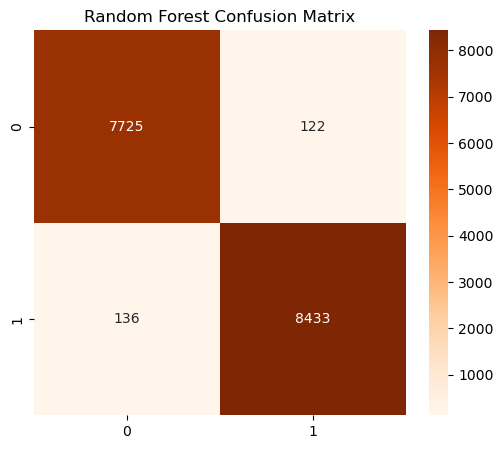

In [61]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
MODEL 4 : Neural Network

In [62]:
from sklearn.neural_network import MLPClassifier

In [63]:
mlp_model = MLPClassifier(

    hidden_layer_sizes=(100,),

    max_iter=300,

    random_state=42

)

In [64]:
mlp_model.fit(X_train, y_train)

,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,300
,shuffle,True
,random_state,42


In [65]:
y_pred_mlp = mlp_model.predict(X_test)

In [66]:
mlp_accuracy = accuracy_score(y_test, y_pred_mlp)

mlp_precision = precision_score(y_test, y_pred_mlp)

mlp_recall = recall_score(y_test, y_pred_mlp)

mlp_f1 = f1_score(y_test, y_pred_mlp)

In [67]:
print("Accuracy :", mlp_accuracy)

print("Precision :", mlp_precision)

print("Recall :", mlp_recall)

print("F1 :", mlp_f1)

Accuracy : 0.9770346003898636
Precision : 0.9776119402985075
Recall : 0.9784105496557358
F1 : 0.9780110819480898


In [68]:
print(classification_report(y_test, y_pred_mlp))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7847
           1       0.98      0.98      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416



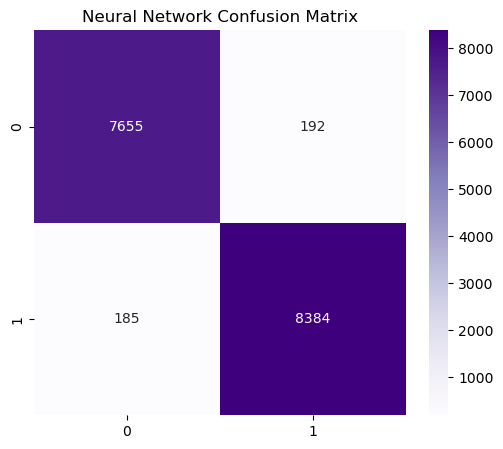

In [69]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Neural Network Confusion Matrix")

plt.show()

In [70]:
mlp_results = {

    "Accuracy": mlp_accuracy,

    "Precision": mlp_precision,

    "Recall": mlp_recall,

    "F1 Score": mlp_f1

}

mlp_results

{'Accuracy': 0.9770346003898636,
 'Precision': 0.9776119402985075,
 'Recall': 0.9784105496557358,
 'F1 Score': 0.9780110819480898}

In [71]:
comparison = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Naive Bayes",

        "Random Forest",

        "Neural Network"

    ],

    "Accuracy":[

        lr_accuracy,

        nb_accuracy,

        rf_accuracy,

        mlp_accuracy

    ],

    "Precision":[

        lr_precision,

        nb_precision,

        rf_precision,

        mlp_precision

    ],

    "Recall":[

        lr_recall,

        nb_recall,

        rf_recall,

        mlp_recall

    ],

    "F1 Score":[

        lr_f1,

        nb_f1,

        rf_f1,

        mlp_f1

    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.979898,0.978622,0.982962,0.980787
1,Naive Bayes,0.960404,0.974476,0.949002,0.961570
2,Random Forest,0.984284,0.985739,0.984129,0.984933
3,Neural Network,0.977035,0.977612,0.978411,0.978011


In [72]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print(best_model)

Model        Random Forest
Accuracy          0.984284
Precision         0.985739
Recall            0.984129
F1 Score          0.984933
Name: 2, dtype: object


In [73]:
print("=" * 50)
print("🏆 BEST MODEL")
print("=" * 50)

print("Model Name :", best_model["Model"])
print("Accuracy   :", round(best_model["Accuracy"] * 100, 2), "%")
print("Precision  :", round(best_model["Precision"] * 100, 2), "%")
print("Recall     :", round(best_model["Recall"] * 100, 2), "%")
print("F1 Score   :", round(best_model["F1 Score"] * 100, 2), "%")

🏆 BEST MODEL
Model Name : Random Forest
Accuracy   : 98.43 %
Precision  : 98.57 %
Recall     : 98.41 %
F1 Score   : 98.49 %


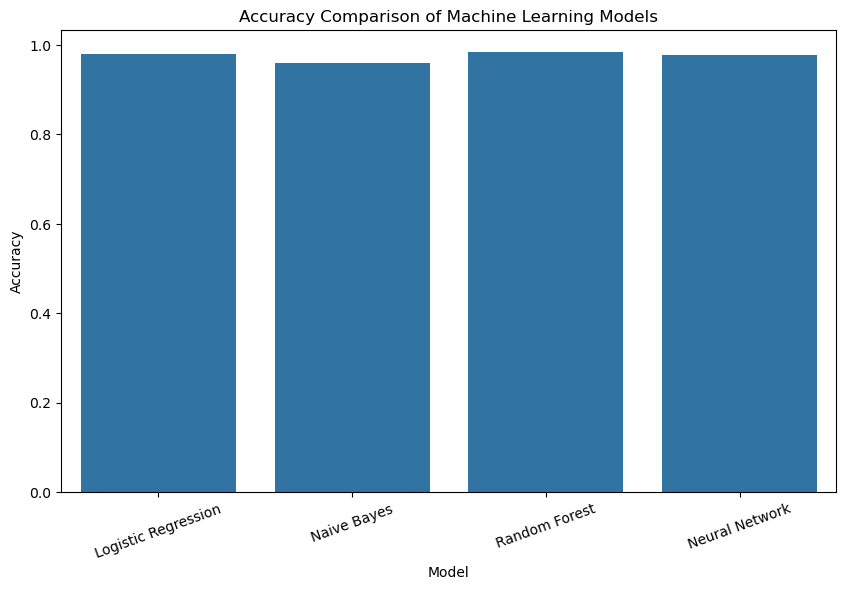

In [74]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison of Machine Learning Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

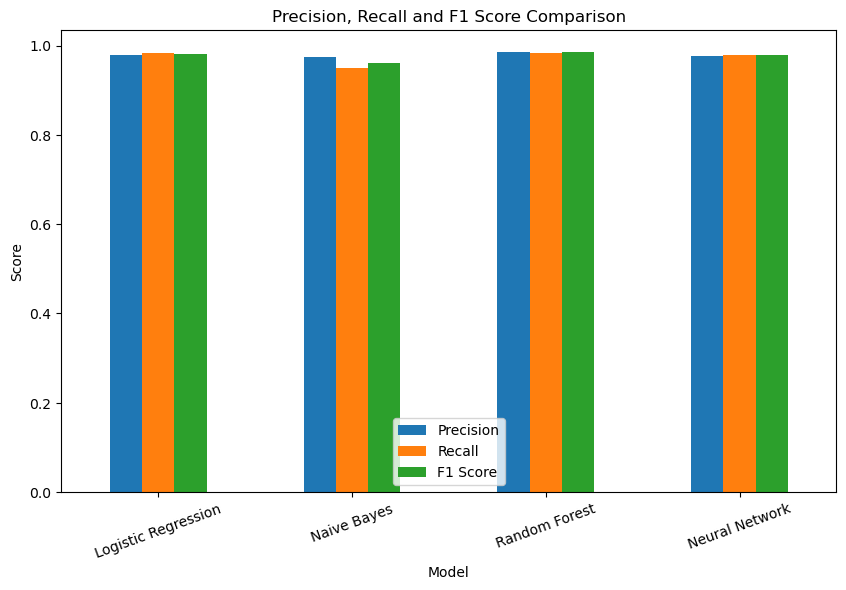

In [75]:
comparison.set_index("Model")[["Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Precision, Recall and F1 Score Comparison")

plt.ylabel("Score")

plt.xticks(rotation=20)

plt.show()

In [76]:
import pickle

In [77]:
with open("best_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

In [78]:
with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

In [79]:
with open("best_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

In [80]:
prediction = loaded_model.predict(X_test[:5])

print(prediction)

[0 1 0 0 1]


In [81]:
def predict_email(email):

    cleaned = clean_text(email)

    vector = tfidf.transform([cleaned])

    prediction = rf_model.predict(vector)

    if prediction[0] == 1:
        return "⚠️ Phishing Email"

    return "✅ Legitimate Email"

In [ ]:
TESTING THE MODEL

In [82]:
sample = """
Congratulations!

You have won $10,000.

Click here immediately to claim your reward.
"""

print(predict_email(sample))

⚠️ Phishing Email


In [20]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(str.maketrans("", "", string.punctuation))

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [26]:
email = """
Subject: Urgent

Dear Customer,

We noticed unusual activity on your account.

Please verify your account immediately by clicking the secure link below.

https://secure-bank-login.com

Regards,
Security Team
"""

detect_email(email)

⚠️ PHISHING EMAIL
Confidence : 85.50%
Legitimate : 14.50%
Phishing   : 85.50%
Risk Level : HIGH


In [27]:
email = """
Subject: Payroll Verification Required

Dear Employee,

As part of our annual payroll verification process, all employees must verify their salary account details before Friday.

Please download the attached payroll verification form and submit the updated information to HR.

If you have any questions, contact the Human Resources Department.

Regards,

Payroll Department
"""

detect_email(email)

✅ LEGITIMATE EMAIL
Confidence : 57.50%
Legitimate : 57.50%
Phishing   : 42.50%
Risk Level : LOW


In [28]:
email = """
Subject: Weekly Team Meeting

Hello Team,

This is a reminder that our weekly team meeting is scheduled for Monday at 9:30 AM.

Agenda:

1. Sprint Review
2. Project Updates
3. Client Feedback
4. Task Allocation

Regards,

Team Lead
"""

detect_email(email)

✅ LEGITIMATE EMAIL
Confidence : 85.00%
Legitimate : 85.00%
Phishing   : 15.00%
Risk Level : LOW


In [29]:
email = """
Hi there,

Our HR department recently shared your contact details with us after you expressed interest in job or internship opportunities with The Developers Arena on LinkedIn.

Because HR only passed along your basic name and email, our hiring managers do not have your resume or experience details yet. Please follow the steps below based on your profile:

💼 If you have experience:
Please reply directly to this email and attach your updated resume. Our engineering and management teams will review it for active lateral openings.
🎓 If you are a fresher:
Please take two minutes to officially complete your candidate profile on our portal so we can route you to our structured tracks:
Complete My Candidate Profile
Application Reference ID: REF-10325015996

If you have already submitted your details on our portal, please disregard this automated follow-up.
"""

detect_email(email)

⚠️ PHISHING EMAIL
Confidence : 52.00%
Legitimate : 48.00%
Phishing   : 52.00%
Risk Level : MEDIUM


In [30]:
email = """
Subject: Project Review Meeting

Hello Aditya,

This is a reminder that the project review meeting is scheduled for tomorrow at 10:30 AM in Conference Room B.

Please bring the latest presentation and project documentation.

Regards,
Project Manager
ABC Technologies
"""

detect_email(email)

✅ LEGITIMATE EMAIL
Confidence : 87.50%
Legitimate : 87.50%
Phishing   : 12.50%
Risk Level : LOW


In [31]:
email = """
Subject: Urgent - Your Bank Account Has Been Suspended

Dear Customer,

We detected suspicious activity in your bank account.

Your account has been temporarily suspended.

Click the secure link below immediately to verify your identity.

http://secure-bank-login-verification.com

Failure to verify within 24 hours will permanently lock your account.

Thank you,

Bank Security Team
"""

detect_email(email)

⚠️ PHISHING EMAIL
Confidence : 93.50%
Legitimate : 6.50%
Phishing   : 93.50%
Risk Level : VERY HIGH


In [32]:
email = """
Subject: Congratulations! You Won the Grand Prize

Congratulations!

You have been selected as the lucky winner of our international lottery.

Claim your reward immediately by clicking the link below.

http://claim-your-prize-now.com

Do not share this email with anyone.

Lottery Promotion Team
"""

detect_email(email)

✅ LEGITIMATE EMAIL
Confidence : 70.28%
Legitimate : 70.28%
Phishing   : 29.72%
Risk Level : LOW


In [33]:
email = """
Subject: Semester Examination Schedule

Dear Students,

The examination schedule for the upcoming semester has been uploaded to the student portal.

Please check your examination dates and report any discrepancies before Friday.

Regards,

Examination Cell
Government Engineering College Palamu
"""

detect_email(email)

✅ LEGITIMATE EMAIL
Confidence : 80.50%
Legitimate : 80.50%
Phishing   : 19.50%
Risk Level : LOW


In [34]:
email = """
Subject: Verify Your PayPal Account

Dear User,

We noticed unusual login attempts on your PayPal account.

Please verify your account immediately.

http://paypal-secure-verification-login.com

Failure to verify may result in permanent suspension.

PayPal Security Department
"""

detect_email(email)

⚠️ PHISHING EMAIL
Confidence : 85.41%
Legitimate : 14.59%
Phishing   : 85.41%
Risk Level : HIGH


In [35]:
email = """
Subject: Interview Confirmation

Dear Candidate,

Thank you for applying for the Software Developer position.

Your interview has been scheduled for Monday at 11:00 AM.

Please bring a copy of your resume and educational certificates.

Best Regards,

Human Resources
XYZ Solutions Pvt. Ltd.
"""

detect_email(email)

✅ LEGITIMATE EMAIL
Confidence : 64.00%
Legitimate : 64.00%
Phishing   : 36.00%
Risk Level : LOW


In [36]:
email = """
Subject: Immediate Password Reset Required

Dear User,

Your Gmail account will be permanently disabled due to suspicious activity.

Reset your password immediately.

http://gmail-security-reset-login.com

Failure to act immediately will result in account deletion.

Google Support Team
"""

detect_email(email)

⚠️ PHISHING EMAIL
Confidence : 80.00%
Legitimate : 20.00%
Phishing   : 80.00%
Risk Level : HIGH


In [37]:
email = """
Subject: Your Amazon Order Has Been Shipped

Hello Aditya,

Your order has been shipped successfully.

Estimated Delivery Date:
25 July 2026

You can track your shipment using your Amazon account.

Thank you for shopping with us.

Amazon Customer Service
"""

detect_email(email)

⚠️ PHISHING EMAIL
Confidence : 51.50%
Legitimate : 48.50%
Phishing   : 51.50%
Risk Level : MEDIUM


In [38]:
email = """
Subject: Income Tax Refund Approved

Dear Taxpayer,

Your income tax refund has been approved.

To receive your refund, please confirm your bank account details immediately.

http://refund-processing-center.com

Income Tax Department
"""

detect_email(email)

⚠️ PHISHING EMAIL
Confidence : 83.18%
Legitimate : 16.82%
Phishing   : 83.18%
Risk Level : HIGH


In [39]:
email = """
Subject: Weekly Team Meeting

Hello Team,

This is a reminder that our weekly team meeting is scheduled for Monday at 9:30 AM.

Agenda:

1. Sprint Review
2. Project Updates
3. Client Feedback
4. Task Allocation

Regards,

Team Lead
"""

detect_email(email)

✅ LEGITIMATE EMAIL
Confidence : 85.00%
Legitimate : 85.00%
Phishing   : 15.00%
Risk Level : LOW


In [40]:
email = """
Subject: Payroll Verification Required

Dear Employee,

As part of our annual payroll verification process, all employees must verify their salary account details before Friday.

Please download the attached payroll verification form and submit the updated information to HR.

If you have any questions, contact the Human Resources Department.

Regards,

Payroll Department
"""

detect_email(email)

✅ LEGITIMATE EMAIL
Confidence : 57.50%
Legitimate : 57.50%
Phishing   : 42.50%
Risk Level : LOW
